<a href="https://colab.research.google.com/github/gerardovazquez-DataAnalyst/ab-testing-landing-page/blob/main/ab_testing_landing_page.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [13]:
#Se cargaron datos previamente a google drive y se otorgó acceso
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# importar librerías
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind          # prueba t — gasto promedio
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
print('Librerías cargadas')


Librerías cargadas


In [15]:
# ── Carga de datos ───────────────────────────────────────────────────
ruta = '/content/drive/MyDrive/Proyecto-Sprint_9_AB_Testing_Ecommerce/'
df= pd.read_csv(ruta + 'landing_experiment.csv')


print('datasets cargados')

datasets cargados


**Vista previa e información general del conjunto de datos**

In [16]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [17]:
# información general
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


None

,converted,gasto
count,40000.00000,40000.000000
mean,0.14265,9.325554
std,0.34972,25.667986
min,0.00000,0.000000
25%,0.00000,0.000000
50%,0.00000,0.000000
75%,0.00000,0.000000
max,1.00000,303.680000


**Insights:**
- El dataset no tiene valores ausentes en ninguna columna.
- La columna `date` es de tipo object y debe convertirse a datetime para análisis temporal.
- La columna `gasto` muestra que el 75% de los usuarios tiene gasto = 0,
  lo cual es consistente con la tasa de conversión del ~14% —
  solo los usuarios convertidos generan gasto.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [18]:
print(df['user_id'].duplicated().sum())
print(df['user_id'].nunique())

0
40000


- user_id: 40,000 usuarios únicos, 0 duplicados.
- Cada fila representa un usuario distinto —
  el supuesto de independencia para las pruebas estadísticas se cumple.

 **Variable `date`**  
Explorar rango de fechas

In [19]:
# Resumen estadístico
df["date"].describe()

,date
count,40000
unique,28
top,2026-01-24
freq,1512


In [20]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


- El experimento duró 28 días (01/01/2026 — 28/01/2026).
- Cubre 4 ciclos semanales completos, eliminando sesgos por día de la semana.
- Con 40,000 usuarios el volumen es suficiente para pruebas estadísticas confiables.

**Variable `gasto` (numérica)**

In [21]:
# Resumen estadístico
df['gasto'].describe()

,gasto
count,40000.000000
mean,9.325554
std,25.667986
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,303.680000


In [22]:
# Resumen estadístico de usuarios que se convirtieron
print(df[df['converted']==1]['gasto'].describe())
tasa_conversion=df['converted'].mean()*100.0
print(f'\nTasa de conversión global: {tasa_conversion:.2f} %')

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

Tasa de conversión global: 14.27 %


- 5,706 usuarios convirtieron de 40,000 → tasa global de 14.27%.
- Gasto promedio de usuarios convertidos: 65.37 con std de 30.90
  — datos dispersos, justifica prueba estadística.
- Rango: 12.12 a 303.68 — hay usuarios de alto valor que podrían
  influir en el promedio.

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [23]:
# Explorar variables categóricas y cómo se distribuyen
columnas=['landing' , 'region', 'dispositivo', 'traffic_source', 'user_type']
for col in columnas:
    print(f"\nConteo de categorías de {col}:")
    print(df[col].value_counts())



Conteo de categorías de landing:
landing
B    20018
A    19982
Name: count, dtype: int64

Conteo de categorías de region:
region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: count, dtype: int64

Conteo de categorías de dispositivo:
dispositivo
Mobile     24829
Desktop    15171
Name: count, dtype: int64

Conteo de categorías de traffic_source:
traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: count, dtype: int64

Conteo de categorías de user_type:
user_type
Nuevo         26033
Recurrente    13967
Name: count, dtype: int64


- Experimento balanceado: A (19,982) vs B (20,018)
- Todas las categorías tienen volumen suficiente para pruebas estadísticas.
- Las frecuencias esperadas en tablas de contingencia serán >> 5
  en todos los casos — supuesto de Chi-cuadrada se cumple anticipadamente.
- Dispositivo: solo Mobile y Desktop — sin categorías minoritarias.
- user_type: Nuevo (26,033) vs Recurrente (13,967).

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [24]:
# Gasto por versión
gasto_A = df[(df['converted']==1) & (df['landing']=='A')]['gasto']
gasto_B = df[(df['converted']==1) & (df['landing']=='B')]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [25]:
print(f'Gasto promedio de A {gasto_A.mean():.2f}')
print(f'Gasto promedio de B {gasto_B.mean():.2f}')
print(f'Página B genera ${(gasto_B.mean()-gasto_A.mean()):.2f} más en promedio que la página A')

Gasto promedio de A 61.09
Gasto promedio de B 68.75
Página B genera $7.66 más en promedio que la página A


### Prueba T
**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de usuarios convertidos es igual en A y B
- **Hipótesis alternativa (H₁):** El gasto promedio de usuarios convertidos es diferente en A y B


In [26]:
# Aplicar prueba
t_test, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico : {t_test}")
print(f"Valor p: {p_value:}")

#Umbral de referencia
alpha = 0.05

if p_value < alpha:
    print('Rechazamos la hipótesis nula: hay evidencia estadística de promedios diferentes')
else:
    print('No rechazamos la hipótesis nula: no hay evidencia estadística de promedios diferentes')

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20
Rechazamos la hipótesis nula: hay evidencia estadística de promedios diferentes


In [44]:

from scipy.stats import levene

# Ejecutar prueba de Levene y mostrar resultados
l_stat, p_value_var = levene(gasto_A, gasto_B)
print(f"Estadístico de Levene: {l_stat}")
print(f"Valor p: {p_value_var}")

alpha = 0.05  # umbral de significancia
if p_value_var < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia de varianzas diferentes (equal_var=True).")


Estadístico de Levene: 29.17646453202917
Valor p: 6.875301988016449e-08
Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).


### 📝 Conclusión e interpretación

**Decisión:** Se rechaza H₀ — hay evidencia estadísticamente significativa
de que el gasto promedio difiere entre versiones (p < 0.05).

**Interpretación de negocio:**
- Gasto promedio página A: 61.09
- Gasto promedio página B: 68.75
- La página B genera 7.66 más por usuario convertido.
- Con p-value de 1.06e-20 la diferencia no es atribuible al azar.

**Recomendación parcial:**
- El gasto promedio favorece a B, sin embargo antes de decidir
  se debe analizar si B también genera mayor tasa de conversión
  — un mayor gasto con menos conversiones podría no ser favorable
  para el negocio en volumen total.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en la página A y B
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre la página A y B

In [28]:
# Número de éxitos por página
convertidos = df.groupby('landing')['converted'].sum()
# Total de registros por página
totales= df.groupby('landing')['converted'].count()

print(f"Usuarios convertidos por página:\n{convertidos}")
print(f"\nTotal de usuarios por página:\n{totales}")

Usuarios convertidos por página:
landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
landing
A    19982
B    20018
Name: converted, dtype: int64


In [29]:
# Calculo de conversión por página
conversion = convertidos*100.0/totales

print(f"Tasa de conversión por página: {conversion}")

Tasa de conversión por página: landing
A    12.571314
B    15.955640
Name: converted, dtype: float64


In [30]:
#Pasar los valores a formato lista
exitos = [convertidos['A'], convertidos['B']]
observaciones = [totales['A'], totales['B']]

In [31]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos, observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Rechazamos H₀: hay evidencia de diferencia en tasas de conversión")
else:
    print("No rechazamos H₀: no hay evidencia de diferencia en tasas de conversión")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22
Rechazamos H₀: hay evidencia de diferencia en tasas de conversión


### 📝 Conclusión e interpretación

**Decisión:**
Se rechaza H₀ — hay evidencia estadísticamente significativa de que
las tasas de conversión difieren entre la página A y la página B
(p-value: 3.76e-22 < 0.05).

**Interpretación de negocio:**
- Tasa de conversión página A: 12.57%
- Tasa de conversión página B: 15.96%
- La página B convierte 3.38 puntos porcentuales más que la página A.
- Con un p-value prácticamente cero, la diferencia no es atribuible al azar.

**Recomendación parcial:**
La tasa de conversión favorece a B. Sin embargo, antes de decidir
se debe analizar si la ventaja de B se mantiene en todos los canales
de tráfico o si está concentrada en uno específico — esto determina
si la implementación debe ser global o segmentada por canal.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-Cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación estadísticamente significativa entre la fuente de tráfico (traffic_source) y la conversión (converted)
- **Hipótesis alternativa (H₁):** Sí existe asociación estadísticamente significativa entre la fuente de tráfico (traffic_source) y la conversión (converted)

In [32]:
# Tabla de contingencia para prueba Chi2
tabla_trafico= pd.crosstab(df['traffic_source'], df['converted'])
tabla_trafico

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [33]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_trafico)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad {dof}")
print(f"\nFrecuencias esperadas:\n{expected}")

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [34]:
# Verificación de supuestos
if np.any(expected < 5):
    print("Supuesto violado: hay celdas con frecuencia esperada < 5")
else:
    print("Supuesto cumplido: todas las frecuencias esperadas son >= 5")

Supuesto cumplido: todas las frecuencias esperadas son >= 5


In [35]:
alpha = 0.05 #umbral de referencia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia de asociación suficiente entre las variables")

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables


In [36]:
#Verificamos porcentajes con tabla normalizada
tabla_trafico_normalizada= pd.crosstab(df['traffic_source'], df['converted'], normalize='index')*100.0
tabla_trafico_normalizada

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


### 📝 Conclusión e interpretación

**Decisión:** Se rechaza H₀ — hay evidencia estadísticamente significativa
de asociación entre la fuente de tráfico y la conversión (p=0.034 < 0.05).

**Interpretación de negocio:**
- Email: 14.99% | Ads: 14.74% | Referral: 13.88% | Organic: 13.79%
- Email lidera con la mayor tasa de conversión.
- Sin embargo, la diferencia máxima entre canales es de 1.2pp —
  estadísticamente significativa pero de relevancia práctica limitada.

**Recomendación parcial:**
Existe asociación entre canal y conversión, pero la magnitud es pequeña.
Se recomienda priorizar Email en estrategia de tráfico, considerando
también el costo por canal antes de reasignar presupuesto.
Este resultado no implica causalidad directa.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba chi-Cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación estadísticamente significativa entre el tipo de usuario (user_type) y la conversión (converted)
- **Hipótesis alternativa (H₁):** Sí existe una asociación estadísticamente significativa entre el tipo de usuario (user_type) y la conversión (converted)

In [37]:
#Tabla de contingencia para prueba chi-cuadrada

tabla_tipo_usuario = pd.crosstab(df['user_type'], df['converted'])
tabla_tipo_usuario

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [38]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_tipo_usuario)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad {dof}")
print(f"\nFrecuencias esperadas:\n{expected}")

Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


In [39]:
# Verificación de supuestos
if np.any(expected < 5):
    print("Supuesto violado: hay celdas con frecuencia esperada < 5")
else:
    print("Supuesto cumplido: todas las frecuencias esperadas son >= 5")

Supuesto cumplido: todas las frecuencias esperadas son >= 5


In [40]:
alpha = 0.05 #umbral de referencia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia de asociación suficiente entre las variables")

No rechazamos la hipótesis nula: no hay evidencia de asociación suficiente entre las variables


In [41]:
#Verificamos porcentajes con tabla normalizada
tabla_tipo_usuario_normalizada = pd.crosstab(df['user_type'], df['converted'], normalize='index')*100.0
tabla_tipo_usuario_normalizada

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


### 📝 Conclusión e interpretación

**Decisión:** No se rechaza H₀ — no hay evidencia estadísticamente
significativa de asociación entre el tipo de usuario y la conversión
(p=0.474 > 0.05).

**Interpretación de negocio:**
- Nuevo: 14.36% | Recurrente: 14.09%
- Diferencia de apenas 0.27pp — estadística y prácticamente insignificante.
- El p-value de 0.474 confirma que la diferencia observada es atribuible al azar.

**Recomendación:**
No se recomienda segmentar la estrategia de marketing por tipo de usuario
basándose en estos datos — ambos perfiles muestran comportamiento
de conversión prácticamente idéntico.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

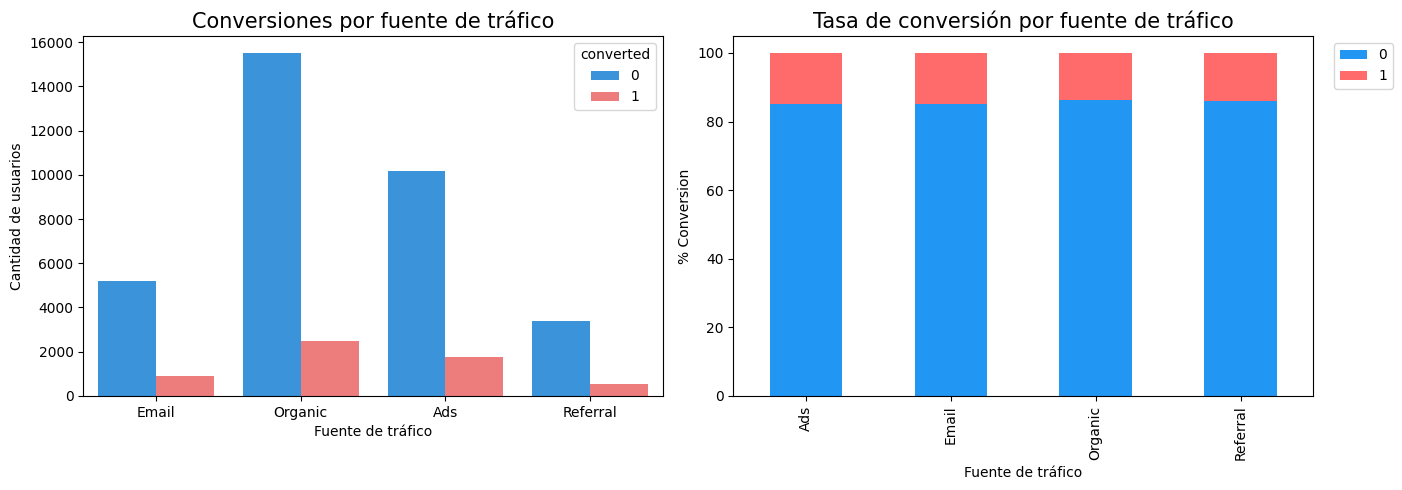

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1
sns.countplot(data=df, x='traffic_source', hue='converted',
              palette=["#2196F3", "#FF6B6B"], ax=ax1)
ax1.set_title('Conversiones por fuente de tráfico', fontsize=15)
ax1.set_xlabel('Fuente de tráfico')
ax1.set_ylabel('Cantidad de usuarios')

# Gráfico 2
tabla_trafico_normalizada.plot(kind='bar', stacked=True,
                       color=["#2196F3", "#FF6B6B"], ax=ax2)
ax2.set_title('Tasa de conversión por fuente de tráfico', fontsize=15)
ax2.set_xlabel('Fuente de tráfico')
ax2.set_ylabel('% Conversion')
ax2.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

**Observaciones:**

- El gráfico apilado confirma lo observado estadísticamente — las tasas
de conversión por canal son similares (~14%), con Email mostrando
una ligera ventaja. La diferencia es estadísticamente significativa
(p=0.034) pero visualmente marginal, lo que refuerza que la
significancia práctica es limitada.
- El gráfico de conteos revela que Organic genera el mayor volumen
de tráfico — dato relevante para decisiones de inversión en canales.

### Relación entre el tipo de usuario y la conversión

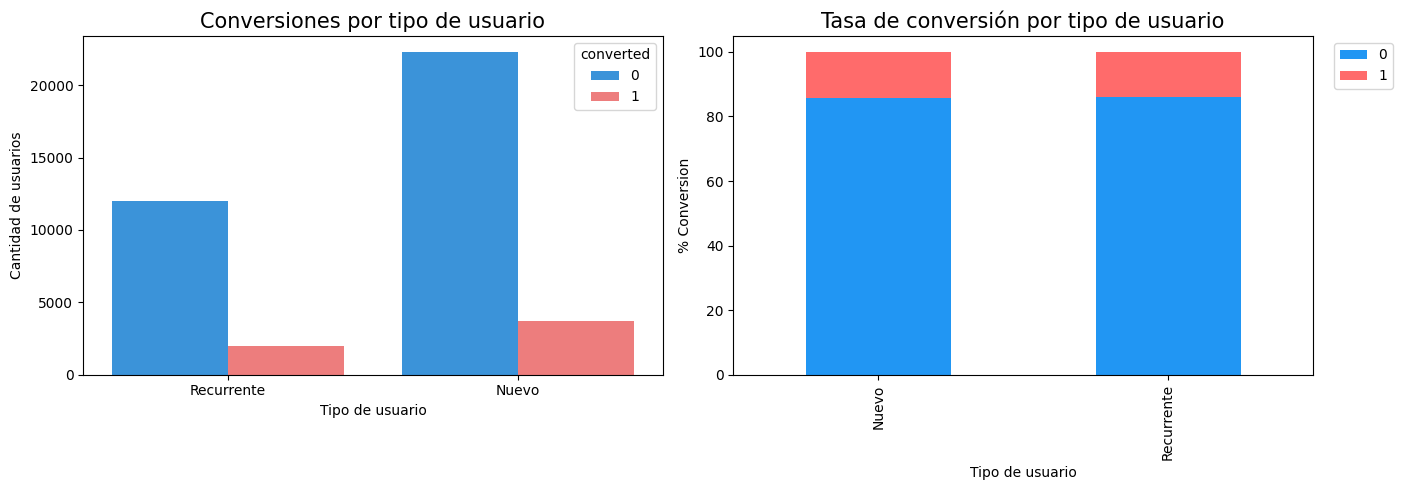

In [43]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1
sns.countplot(data=df, x='user_type', hue='converted',
              palette=["#2196F3", "#FF6B6B"], ax=ax1)
ax1.set_title('Conversiones por tipo de usuario', fontsize=15)
ax1.set_xlabel('Tipo de usuario')
ax1.set_ylabel('Cantidad de usuarios')

# Gráfico 2
tabla_tipo_usuario_normalizada.plot(kind='bar', stacked=True,
                       color=["#2196F3", "#FF6B6B"], ax=ax2)
ax2.set_title('Tasa de conversión por tipo de usuario', fontsize=15)
ax2.set_xlabel('Tipo de usuario')
ax2.set_ylabel('% Conversion')
ax2.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

**Observaciones:**

- El gráfico apilado confirma lo observado estadísticamente —
las tasas de conversión entre usuarios Nuevos (14.36%) y
Recurrentes (14.09%) son prácticamente idénticas visualmente.
- El gráfico de conteos muestra que hay más usuarios Nuevos (26,033)
que Recurrentes (13,967) — dato útil para estrategia de adquisición,
pero que no implica diferencia en comportamiento de conversión.

## 🧩 Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?

## 🌟Reporte Ejecutivo basado en el Experimento A/B

#### 🔍 Comparación de página (A vs B)

**Gasto promedio por usuario que convirtió:**
- Página A: 61.09 | Página B: 68.75
- La página B genera $7.66 más por usuario convertido.
- **Interpretación:** Con un p-value de 1.06e-20, la diferencia en gasto
  promedio es estadísticamente significativa y no atribuible al azar.

<br>

**Tasa de conversión:**
- Página A: 12.57% | Página B: 15.96%
- La página B convierte 3.38 puntos porcentuales más que la página A.
- **Interpretación:** Con un p-value de 3.76e-22, hay evidencia
  contundente de que B supera a A en tasa de conversión.
  Combinado con el mayor gasto promedio, la página B genera
  más valor económico por usuario expuesto.

---

#### 📊 Segmentación por fuente de tráfico
- Se encontró asociación estadísticamente significativa entre
  la fuente de tráfico y la conversión (p=0.034 < 0.05).
- Email lidera con 14.99%, seguido de Ads (14.74%),
  Referral (13.88%) y Organic (13.79%).
- **Interpretación:** Aunque la asociación es estadísticamente
  significativa, la diferencia máxima entre canales es de 1.2pp —
  relevancia práctica limitada. Organic genera el mayor volumen
  de tráfico pero la menor tasa de conversión.

---

#### 📊 Segmentación por tipo de usuario
- No se encontró asociación estadísticamente significativa entre
  el tipo de usuario y la conversión (p=0.474 > 0.05).
- Nuevo: 14.36% | Recurrente: 14.09% — diferencia de 0.27pp.
- **Interpretación:** El comportamiento de conversión es
  prácticamente idéntico entre usuarios nuevos y recurrentes.
  No existe evidencia para segmentar estrategias por este criterio.

---

#### 💡 Recomendaciones de negocio

- **Implementar página B globalmente** — supera a A tanto en tasa
  de conversión (+3.38pp) como en gasto promedio por usuario
  convertido (+$7.66), con evidencia estadística contundente
  en ambas métricas.

- **Priorizar inversión en canal Email** — aunque la diferencia
  entre canales es marginal, Email muestra consistentemente
  la mayor tasa de conversión. Se recomienda evaluar el costo
  por adquisición de cada canal antes de reasignar presupuesto.

- **No segmentar por tipo de usuario** — no existe evidencia
  estadística de diferencia en conversión entre usuarios nuevos
  y recurrentes. Los recursos destinados a estrategias
  diferenciadas por este criterio no están justificados
  por los datos actuales.